# Elbow và Silhouette

Hai cách này giúp **chọn `K` cho k-Means**. kNN không dùng hai đồ thị này; kNN chọn `K` bằng accuracy trên tập test.

DBSCAN không nhận `K`. Silhouette vẫn dùng được sau khi đã fit, để chấm chất lượng cụm. Elbow thì không dùng cho DBSCAN.


## 1. Elbow — chỗ khuỷu tay

Với mỗi `K` từ 1 đến `k_max`, fit `KMeans` và lưu `inertia_`.

$$
\text{inertia} = \sum_i \| x_i - c_{y_i} \|^2
$$

`c_{y_i}` là tâm cụm của điểm `x_i`. Inertia là tổng bình phương khoảng cách từ mỗi điểm tới tâm cụm của nó. `K` tăng thì inertia giảm, vì cụm nhỏ hơn và điểm nằm gần tâm hơn.

Vẽ inertia theo `K`. Đoạn đầu đường dốc xuống mạnh: thêm một cụm còn đáng. Chỗ đường gãy rồi đi ngang là **khuỷu tay**. `K` ở chỗ đó là `K` nên thử. Thêm cụm nữa thì inertia giảm rất ít.

Cùng cách với hàm `ve_elbow` trong `06_TH-kMeans.ipynb`: `n_init=10`, `random_state=3000`.


## 2. Silhouette — điểm gần cụm mình, xa cụm khác

Với mỗi điểm `i`:

- `a(i)`: khoảng cách trung bình từ `i` tới các điểm **cùng cụm**.
- `b(i)`: khoảng cách trung bình từ `i` tới cụm **khác gần nhất**.

$$
s(i) = \frac{b(i) - a(i)}{\max\bigl(a(i),\, b(i)\bigr)}
$$

`s(i)` nằm trong `[-1, 1]`.

- Gần `1`: điểm nằm đúng cụm của nó.
- Gần `0`: điểm nằm ở biên hai cụm.
- Âm: điểm có vẻ gần cụm khác hơn cụm đang gán.

Điểm của cả lần gom là trung bình mọi `s(i)`, hàm `silhouette_score`. **Càng cao càng tốt.** Chỉ tính được khi có **ít nhất 2 cụm**, nên vòng lặp bắt đầu từ `K = 2`, không từ 1.

Với DBSCAN, nhãn `-1` là nhiễu. File thực hành tính hai lần: giữ noise, và bỏ các điểm `-1` rồi mới gọi `silhouette_score`. Nếu còn dưới 2 cụm thì không tính.


## 3. Hai cách đọc cùng một `K`

| | Elbow | Silhouette |
|---|---|---|
| Hỏi | Thêm cụm còn giảm inertia đáng không? | Điểm có nằm gọn trong cụm của nó không? |
| `K` nhỏ nhất | 1 | 2 |
| Chọn | Chỗ khuỷu, đường bắt đầu đi ngang | `K` có `silhouette_score` cao nhất |
| Dùng cho | k-Means | k-Means, và chấm DBSCAN sau khi đã có nhãn |

Hai đồ thị thường chỉ cùng một vùng `K`. Nếu lệch, xem scatter: elbow tránh tách vụn, silhouette tránh gom hai đám xa vào một cụm.


In [1]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

centers = np.array([[0, 0], [8, 0], [0, 8], [8, 8]])
X, _ = make_blobs(n_samples=300, centers=centers, cluster_std=0.6, random_state=3000)
X_scaled = StandardScaler().fit_transform(X)
print(X_scaled.shape)


(300, 2)


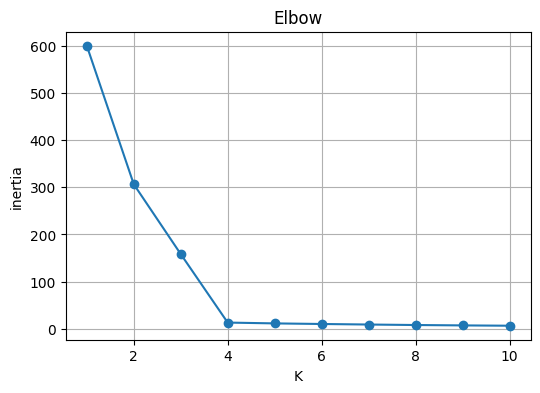

[(1, 600.0), (2, 306.4), (3, 158.4), (4, 13.1), (5, 11.4), (6, 10.2), (7, 9.0), (8, 8.0), (9, 7.1), (10, 6.5)]


In [2]:
def ve_elbow(X_scaled, k_max=10):
    ks = list(range(1, k_max + 1))
    inertias = []
    for k in ks:
        model = KMeans(n_clusters=k, n_init=10, random_state=3000)
        model.fit(X_scaled)
        inertias.append(model.inertia_)
    plt.figure(figsize=(6, 4))
    plt.plot(ks, inertias, marker='o')
    plt.xlabel('K')
    plt.ylabel('inertia')
    plt.title('Elbow')
    plt.grid(True)
    plt.show()
    return ks, inertias


ks_elbow, inertias = ve_elbow(X_scaled)
print(list(zip(ks_elbow, np.round(inertias, 1))))


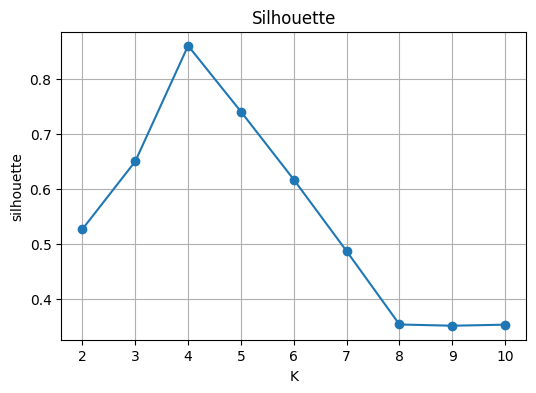

[(2, 0.527), (3, 0.65), (4, 0.86), (5, 0.74), (6, 0.617), (7, 0.487), (8, 0.354), (9, 0.352), (10, 0.354)]
K silhouette cao nhất: 4


In [3]:
def ve_silhouette(X_scaled, k_max=10):
    ks = list(range(2, k_max + 1))
    scores = []
    for k in ks:
        labels = KMeans(n_clusters=k, n_init=10, random_state=3000).fit_predict(X_scaled)
        scores.append(silhouette_score(X_scaled, labels))
    plt.figure(figsize=(6, 4))
    plt.plot(ks, scores, marker='o')
    plt.xlabel('K')
    plt.ylabel('silhouette')
    plt.title('Silhouette')
    plt.grid(True)
    plt.show()
    return ks, scores


ks_sil, scores = ve_silhouette(X_scaled)
print(list(zip(ks_sil, np.round(scores, 3))))
print('K silhouette cao nhất:', ks_sil[int(np.argmax(scores))])


Dữ liệu giả này có **4** đám. Elbow gãy quanh `K = 4`. Silhouette cũng cao nhất ở `K = 4`.

Trên dữ liệu thật, khuỷu tay ít khi nhọn như vậy. Chọn `K` ở chỗ giảm chậm lại, rồi mở scatter để kiểm tra các cụm có tách được không.
